In [ ]:
!pip install rdkit datasets tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.7/36.7 MB 16.3 MB/s eta 0:00:00


In [ ]:
from datasets import load_dataset
import pandas as pd

ds = load_dataset("yairschiff/zinc250k")

df = pd.DataFrame(ds["train"].to_pandas())

df = df.sample(10000, random_state=42)

smiles_list = df["smiles"].tolist()

print("Number of molecules:", len(smiles_list))
print(smiles_list[:5])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:86: UserWarning: 
Access to the secret `HF_TOKEN` has not been granted on this notebook.
You will not be requested again.
Please restart the session if you want to be prompted again.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/19.9M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/2.20M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/224568 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/24887 [00:00<?, ? examples/s]

Number of molecules: 10000
['COc1ccc([C@@H]([NH3+])c2cscc2C)cc1C', 'CC(C)Cn1ccnc(NC[C@](C)(O)c2cccs2)c1=O', 'Cc1ccc(F)cc1C(=O)Nc1cccc(OC[C@@H]2CCCO2)c1', 'C[C@@H]1CCC[C@]2(CC(=O)NC(=O)[C@@H]2C)C1', 'COc1cccc(COc2ccc(C)nc2C[NH3+])n1']


tokenize SMILES

In [ ]:
smiles_list = ["^" + s + "$" for s in smiles_list]

chars = sorted(list(set("".join(smiles_list))))

chars.append("<PAD>")


stoi = {ch:i for i,ch in enumerate(chars)}
itos = {i:ch for ch,i in stoi.items()}

pad_idx = stoi["<PAD>"]

vocab_size = len(chars)

print("Vocab size:", vocab_size)

Vocab size: 43


create training sequences

In [ ]:
import torch
max_len = max(len(s) for s in smiles_list)

def encode(smiles):

    seq = [stoi[c] for c in smiles]

    # pad sequence
    seq = seq + [pad_idx]*(max_len - len(seq))

    return seq

encoded = [encode(s) for s in smiles_list]

create dataset class

In [ ]:
from torch.utils.data import Dataset

class SmilesDataset(Dataset):

    def __init__(self, sequences):
        self.data = sequences

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):

        seq = self.data[idx]

        x = seq[:-1]
        y = seq[1:]

        return torch.tensor(x), torch.tensor(y)

dataset = SmilesDataset(encoded)

In [ ]:
from torch.utils.data import DataLoader

loader = DataLoader(dataset, batch_size=64, shuffle=True, drop_last=True)

LSTM 

In [ ]:
import torch.nn as nn

class SmilesLSTM(nn.Module):

    def __init__(self, vocab_size):

        super().__init__()

        self.embedding = nn.Embedding(vocab_size, 128)

        self.lstm = nn.LSTM(
            input_size=128,
            hidden_size=256,
            num_layers=2,
            batch_first=True
        )

        self.fc = nn.Linear(256, vocab_size)

    def forward(self, x):

        x = self.embedding(x)

        out, _ = self.lstm(x)

        out = self.fc(out)

        return out

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = SmilesLSTM(vocab_size).to(device)

criterion = nn.CrossEntropyLoss(ignore_index=pad_idx)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

training loop

In [ ]:
from tqdm import tqdm

epochs = 30

model.train()

for epoch in range(epochs):

    total_loss = 0

    for x,y in tqdm(loader):

        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        output = model(x)

        loss = criterion(
            output.view(-1, vocab_size),
            y.view(-1)
        )

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    print("Epoch:", epoch, "Loss:", total_loss/len(loader))

100%|██████████| 156/156 [00:03<00:00, 41.71it/s]


Epoch: 0 Loss: 1.453870489047124


100%|██████████| 156/156 [00:03<00:00, 44.89it/s]


Epoch: 1 Loss: 0.77250642539599


100%|██████████| 156/156 [00:03<00:00, 44.22it/s]


...

Epoch: 27 Loss: 0.4219929581651321


100%|██████████| 156/156 [00:03<00:00, 43.74it/s]


Epoch: 28 Loss: 0.4170241806751642


100%|██████████| 156/156 [00:03<00:00, 44.66it/s]

Epoch: 29 Loss: 0.41204609779211193


generation

In [ ]:
import torch.nn.functional as F

def generate(model, max_len=100):

    model.eval()

    token = torch.tensor([[stoi["^"]]]).to(device)

    result = ""

    for _ in range(max_len):

        output = model(token)

        probs = F.softmax(output[0, -1], dim=0)

        idx = torch.multinomial(probs, 1).item()

        char = itos[idx]

        if char == "$":
            break

        result += char

        token = torch.cat(
            [token, torch.tensor([[idx]]).to(device)],
            dim=1
        )

    return result

In [ ]:
for _ in range(10):
    print(generate(model))

<START>Cc1cc([C@H](C)NC(=O)c2nc(C3CC3)n(C)n2)cs1<END>
<START>Cc1cc(CS(=O)(=O)CC(C)C)cn1Cc1ccccc1C#N<END>
<START>COCCN(CC#N)=C1S(=O)(=O)c2ccc(Cl)cc2(C)C1<END>
<START>CNC(=O)c1cc(C[NH+]2CCC(C)(C)[C@@H](C)C2)cc(-c2ccccc2)n1<END>
<START>CC1CC[NH+](CCNC(=O)[C@@H]2CC(=O)N([C@H]3CCS(=O)(=O)C3)C2)CCCC1<END>
<START>O=C(Nc1ccccc1)c1ccc(-c2nn(C)c3ncccc23)cc1<END>
<START>O=C(NNC(=O)c1cc(F)ccc1Br)c1ccccc1<END>
<START>CCOC(=O)c1sc2sc(C)cc2c1=O<END>
<START>Cn1c(=O)c(/N=C([O-])[C@@H]2C[C@H]3CC[C@@H]2C3)[nH]c1C(C)C<END>
<START>CCN(CC)C(=O)[C@@H]1CSCN1C(=O)Cc1ccc(F)cc1<END>


In [ ]:
generated = []

for _ in range(1000):
    generated.append(generate(model))

validation

In [ ]:
from rdkit import Chem

valid = []

for _ in range(100):
    smi = generate(model)

    smi = smi.replace("<START>", "").replace("<END>", "")

    mol = Chem.MolFromSmiles(smi)

    if mol is not None:
        valid.append(smi)

print("Valid molecules:", len(valid))

[11:15:04] SMILES Parse Error: extra close parentheses while parsing: Cn1c([O-])c2cc(C(=O)N3CC[NH+](C4CCCCCC4)CC3)on2)cn1
[11:15:04] SMILES Parse Error: check for mistakes around position 48:
[11:15:04] +](C4CCCCCC4)CC3)on2)cn1
[11:15:04] ~~~~~~~~~~~~~~~~~~~~^
[11:15:04] SMILES Parse Error: Failed parsing SMILES 'Cn1c([O-])c2cc(C(=O)N3CC[NH+](C4CCCCCC4)CC3)on2)cn1' for input: 'Cn1c([O-])c2cc(C(=O)N3CC[NH+](C4CCCCCC4)CC3)on2)cn1'
[11:15:05] SMILES Parse Error: unclosed ring for input: 'CN(c1cc[nH+]c(N)c1)C[C@@H]2CCCO1'
[11:15:05] Can't kekulize mol.  Unkekulized atoms: 12 14 19
[11:15:06] SMILES Parse Error: unclosed ring for input: 'CN(C)c1nc(C[NH+]2CCN(C(=O)c3ccc4c(C)cc4cc[nH]c4c3)CC2)cs1'
[11:15:06] Explicit valence for atom # 8 Cl, 2, is greater than permitted
[11:15:06] SMILES Parse Error: syntax error while parsing: N#Cc1c(F)cccc1NC(=O)CSc1nc2sccn2c1[N+
[11:15:06] SMILES Parse Error: check for mistakes around position 37:
[11:15:06] (=O)CSc1nc2sccn2c1[N+
[11:15:06] ~~~~~~~~~~~~~~~

Valid molecules: 60


In [ ]:
from rdkit.Chem import QED

scores = []

for smi in valid:
    mol = Chem.MolFromSmiles(smi)
    score = QED.qed(mol)
    scores.append((smi, score))

scores = sorted(scores, key=lambda x: x[1], reverse=True)


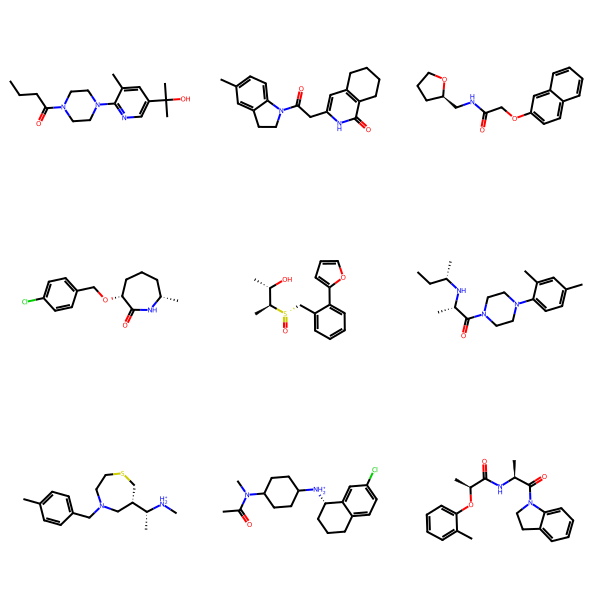

In [ ]:
from rdkit.Chem import Draw

mols = [Chem.MolFromSmiles(s) for s,_ in scores[:9]]

Draw.MolsToGridImage(mols, molsPerRow=3)

In [ ]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Descriptors, QED

rows = []

for smi in valid:
    mol = Chem.MolFromSmiles(smi)

    rows.append({
        "SMILES": smi,
        "MW": Descriptors.MolWt(mol),
        "LogP": Descriptors.MolLogP(mol),
        "HBD": Descriptors.NumHDonors(mol),
        "HBA": Descriptors.NumHAcceptors(mol),
        "QED": QED.qed(mol)
    })

df = pd.DataFrame(rows)

df.head(10)

,SMILES,MW,LogP,HBD,HBA,QED
0,O=C1CC(=C2/C(=O)N([C@H](C#N)C(=O)[O-])C2=O)C(C...,291.239,-1.73302,0,7,0.255665
1,NC(=O)NC1CN(c2cc[nH+]cc2N[C@H]2CSCO2)c1,296.376,-0.18350,3,5,0.716255
2,CC[C@@]1(C)CCCC[C@H]1NC(=O)N[C@@H](C)[C@@H](C)...,311.470,2.75730,2,2,0.819891
3,CC[C@@H](NCc1cc(F)c(F)c(F)c1F)[NH+](C)C(C)C,293.328,1.99180,2,1,0.354837
4,Cn1ccnc1CNC(=O)N1CCC[C@@H]1c1nc(-c2nc(C3CC3)no...,396.455,2.12770,1,6,0.707946
5,CCc1ccc(CNC(=O)C(=O)NCc2nc(C)no2)cc1,302.334,0.87302,2,5,0.798882
6,COc1ccccc1-c1csc(NC(=O)N(C)Cc2cccc(Cl)c2)n1,387.892,5.13600,1,4,0.659314
7,Cc1cccnc1SCC(=O)NCC(C)(C)Oc1cccc(N)c1,345.468,3.03812,2,5,0.595662
8,c1ccc(C[S@](=O)[C@@H](C)[C@H](C)O)c(-c2ccco2)c1,278.373,2.96460,1,3,0.914463
9,C[C@@H](Cc1nnc(-c2ccccc2)n1C)C(=O)Nc1ccc([N+](...,379.420,3.51602,1,5,0.521317


In [ ]:
train_set = set(smi)

novel = [s for s,_ in scores if s not in train_set]

print("Novel molecules:", len(novel))

Novel molecules: 60
